# Session 1 for pytorch we need to revise RNN and stuff

In [11]:
#Define a simple pytorch class

import torch
import torch.nn as nn

class RNNCell(nn.Module):
  """
  1.nn.Linear is just X * W + b — the weight matrix multiplication we wrote in the equation. And we inherit from nn.Module because PyTorch needs to know this is a model — it handles parameter tracking, .to(device), .parameters() for the optimizer, all that stuff automatically.

  2.RNN is just h_new = tanh(W_x(x) + W_h(h_prev))

  3. nn.Embedding. You give it a vocabulary size and an embedding dimension, and it learns a vector for each word during training.
  """
  def __init__(self, input_size, hidden_size):
    """
    input_size: the size of the input vector
    hidden_size: the size of the hidden state vector
    """
    super().__init__()
    self.W_x = nn.Linear(input_size, hidden_size)
    self.W_h = nn.Linear(hidden_size, hidden_size)

  def forward(self, x, h_prev):
        return torch.tanh(self.W_x(x) + self.W_h(h_prev))

In [12]:
#Define the forward pass for RNN using RNN Cell we created above
class RNN(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.cell = RNNCell(embed_size, hidden_size)
        self.fc = nn.Linear(hidden_size, vocab_size)


    def forward(self, x):
        h = torch.zeros(x.size(0), hidden_size)#Intial Hidden state
        all_scores = []
        for t in range(x.size(1)):
            x_t = self.embedding(x[:, t]) #at every step garb the  t-th word from every sentence and convert to vectors
            h = self.cell(x_t, h)#Pass current word vectors + previous hidden state into RNN cell. Get new hidden state back
            scores = self.fc(h)
            all_scores.append(scores)
        return all_scores

In [13]:
#Define a dummy corpus and create a vocab
corpus = [
    "the cat sat on the mat",
    "the dog ran on the road",
    "the cat ran fast",
    "the dog sat still",
    "a cat and a dog sat",
    "the mat is on the floor",
    "a dog ran to the cat",
    "the cat is fast",
]

words = sorted(set(" ".join(corpus).split()))

word2idx = {word: idx for idx, word in enumerate(words)}

print("vocabulary:", word2idx)
print("vocab size:", len(word2idx))

vocabulary: {'a': 0, 'and': 1, 'cat': 2, 'dog': 3, 'fast': 4, 'floor': 5, 'is': 6, 'mat': 7, 'on': 8, 'ran': 9, 'road': 10, 'sat': 11, 'still': 12, 'the': 13, 'to': 14}
vocab size: 15


In [14]:
#Convert the sentences to indices
def sentence_to_indices(sentence, word2idx):
    return [word2idx[word] for word in sentence.split()]

# convert all sentences
data = [sentence_to_indices(s, word2idx) for s in corpus]

for i, (sentence, indices) in enumerate(zip(corpus, data)):
    print(f"{sentence}")
    print(f"{indices}")
    print()

the cat sat on the mat
[13, 2, 11, 8, 13, 7]

the dog ran on the road
[13, 3, 9, 8, 13, 10]

the cat ran fast
[13, 2, 9, 4]

the dog sat still
[13, 3, 11, 12]

a cat and a dog sat
[0, 2, 1, 0, 3, 11]

the mat is on the floor
[13, 7, 6, 8, 13, 5]

a dog ran to the cat
[0, 3, 9, 14, 13, 2]

the cat is fast
[13, 2, 6, 4]



In [6]:
max_len = max(len(s) for s in data)
print("max length:", max_len)

# pad all sentences to max_len
def pad_sequence(seq, max_len, pad_idx=0):
    return seq + [pad_idx] * (max_len - len(seq))

padded_data = [pad_sequence(s, max_len) for s in data]

for i, (sentence, padded) in enumerate(zip(corpus, padded_data)):
    print(f"{sentence}")
    print(f"{padded}")
    print()

max length: 6
the cat sat on the mat
[2, 5, 4, 12, 2, 10]

the dog ran on the road
[2, 8, 9, 12, 2, 3]

the cat ran fast
[2, 5, 9, 11, 0, 0]

the dog sat still
[2, 8, 4, 0, 0, 0]

a cat and a dog sat
[13, 5, 1, 13, 8, 4]

the mat is on the floor
[2, 10, 14, 12, 2, 6]

a dog ran to the cat
[13, 8, 9, 7, 2, 5]

the cat is fast
[2, 5, 14, 11, 0, 0]



In [15]:
# add <PAD> token to vocabulary
word2idx['<PAD>'] = len(word2idx)
pad_idx = word2idx['<PAD>']

print("pad index:", pad_idx)
print("vocab size now:", len(word2idx))

# redo padding with proper pad_idx
padded_data = [pad_sequence(s, max_len, pad_idx) for s in data]

for sentence, padded in zip(corpus, padded_data):
    print(f"{sentence}")
    print(f"{padded}")
    print()

pad index: 15
vocab size now: 16
the cat sat on the mat
[13, 2, 11, 8, 13, 7]

the dog ran on the road
[13, 3, 9, 8, 13, 10]

the cat ran fast
[13, 2, 9, 4, 15, 15]

the dog sat still
[13, 3, 11, 12, 15, 15]

a cat and a dog sat
[0, 2, 1, 0, 3, 11]

the mat is on the floor
[13, 7, 6, 8, 13, 5]

a dog ran to the cat
[0, 3, 9, 14, 13, 2]

the cat is fast
[13, 2, 6, 4, 15, 15]



In [16]:
import torch

# convert to tensor
x = torch.tensor(padded_data)

print("shape:", x.shape)
print(x)

shape: torch.Size([8, 6])
tensor([[13,  2, 11,  8, 13,  7],
        [13,  3,  9,  8, 13, 10],
        [13,  2,  9,  4, 15, 15],
        [13,  3, 11, 12, 15, 15],
        [ 0,  2,  1,  0,  3, 11],
        [13,  7,  6,  8, 13,  5],
        [ 0,  3,  9, 14, 13,  2],
        [13,  2,  6,  4, 15, 15]])


In [17]:
vocab_size = len(word2idx)
embed_size = 8
hidden_size = 4
#do a forward pass so for each sentence we get a hidden state
model = RNN(vocab_size, embed_size, hidden_size)
all_scores = model(x)
print(all_scores)
print("number of time steps:", len(all_scores))
print("scores shape at t=0:", all_scores[0].shape)

[tensor([[ 0.0457,  0.3269, -0.1215,  0.8203, -0.8323, -0.5188,  0.0529, -0.8081,
         -0.0039, -0.1447, -0.0832,  0.3428,  0.0672,  0.1575,  0.4270,  0.4909],
        [ 0.0457,  0.3269, -0.1215,  0.8203, -0.8323, -0.5188,  0.0529, -0.8081,
         -0.0039, -0.1447, -0.0832,  0.3428,  0.0672,  0.1575,  0.4270,  0.4909],
        [ 0.0457,  0.3269, -0.1215,  0.8203, -0.8323, -0.5188,  0.0529, -0.8081,
         -0.0039, -0.1447, -0.0832,  0.3428,  0.0672,  0.1575,  0.4270,  0.4909],
        [ 0.0457,  0.3269, -0.1215,  0.8203, -0.8323, -0.5188,  0.0529, -0.8081,
         -0.0039, -0.1447, -0.0832,  0.3428,  0.0672,  0.1575,  0.4270,  0.4909],
        [-0.4570,  0.6385, -0.4842,  0.0395, -0.2734, -0.1887, -0.0180, -0.4381,
          0.2453, -0.0684, -0.4221, -0.0353,  0.4922,  0.2931,  0.6153,  0.1522],
        [ 0.0457,  0.3269, -0.1215,  0.8203, -0.8323, -0.5188,  0.0529, -0.8081,
         -0.0039, -0.1447, -0.0832,  0.3428,  0.0672,  0.1575,  0.4270,  0.4909],
        [-0.4570,  0.

**# Now — this hidden state is just a compressed summary of each sentence.**

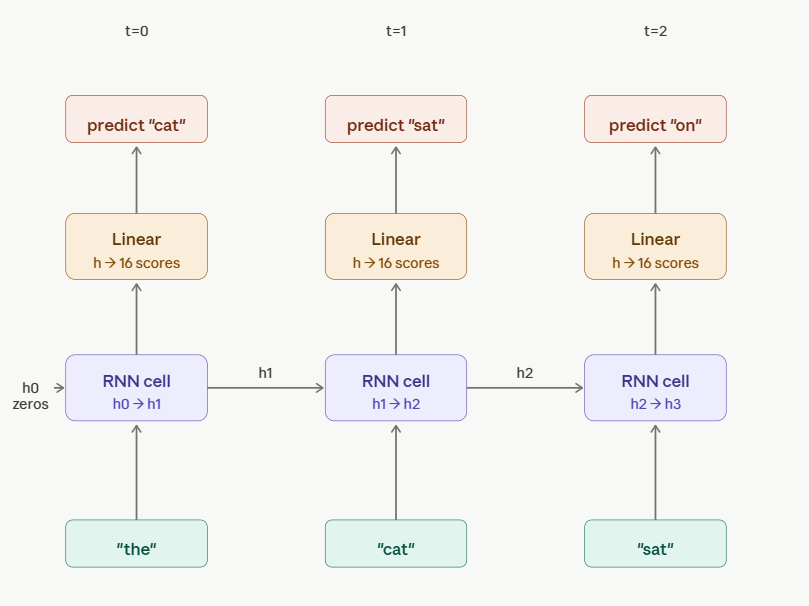

In [18]:
import torch

# take scores at t=0
scores_t0 = all_scores[0]  # shape [8, 16]

# get index of highest score for each sentence
predicted_indices = torch.argmax(scores_t0, dim=1)
print("predicted indices:", predicted_indices)

# convert indices back to words
idx2word = {idx: word for word, idx in word2idx.items()}
predicted_words = [idx2word[i.item()] for i in predicted_indices]
print("predicted words:", predicted_words)


predicted indices: tensor([3, 3, 3, 3, 1, 3, 1, 3])
predicted words: ['dog', 'dog', 'dog', 'dog', 'and', 'dog', 'and', 'dog']


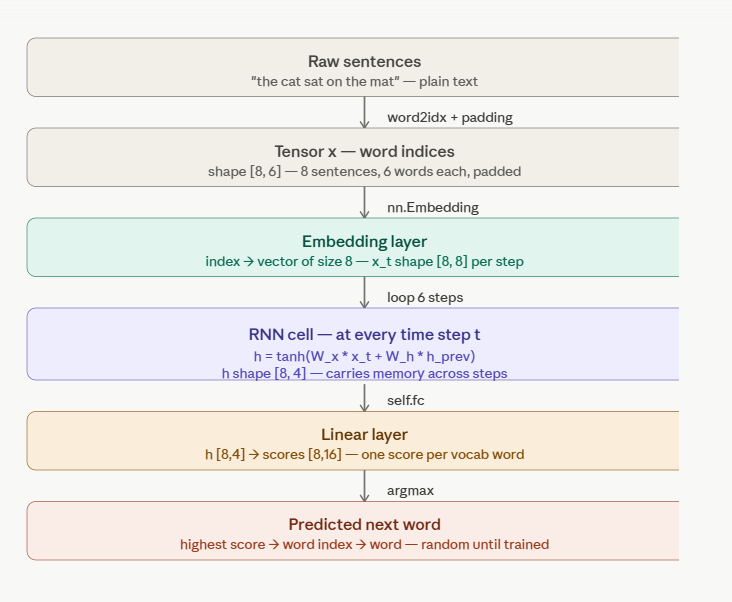

# # Training loop

In [20]:
input_x = x[:, :-1]
target = x[:, 1:]

print("input_x shape:", input_x.shape)
print("target shape:", target.shape)
print("input_x[0]:", input_x[0])
print("target[0]:", target[0])

input_x shape: torch.Size([8, 5])
target shape: torch.Size([8, 5])
input_x[0]: tensor([13,  2, 11,  8, 13])
target[0]: tensor([ 2, 11,  8, 13,  7])


In [21]:
# Loss function and optimizer
import torch.optim as optim

model = RNN(vocab_size, embed_size, hidden_size)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [23]:
all_scores = model(input_x)

all_scores = torch.stack(all_scores, dim=1)  # [8, 5, 16]
print("stacked scores shape:", all_scores.shape)

all_scores = all_scores.reshape(-1, vocab_size)  # [40, 16]
target_flat = target.reshape(-1)                  # [40]

print("scores shape:", all_scores.shape)
print("target shape:", target_flat.shape)

stacked scores shape: torch.Size([8, 5, 16])
scores shape: torch.Size([40, 16])
target shape: torch.Size([40])


In [24]:
loss = criterion(all_scores, target_flat)
print("loss:", loss.item())

loss: 2.8816261291503906


# Training loop

In [25]:
# Training loop

In [28]:
model = RNN(vocab_size, embed_size, hidden_size)
optimizer = optim.Adam(model.parameters(), lr=0.01)

for epoch in range(500):
    optimizer.zero_grad()
    
    all_scores = model(input_x)
    all_scores = torch.stack(all_scores, dim=1).reshape(-1, vocab_size)
    target_flat = target.reshape(-1)
    
    loss = criterion(all_scores, target_flat)
    loss.backward()
    optimizer.step()
    
    if epoch % 100 == 0:
        print(f"epoch {epoch} loss: {loss.item():.4f}")

epoch 0 loss: 2.9404
epoch 100 loss: 1.1077
epoch 200 loss: 0.8737
epoch 300 loss: 0.6940
epoch 400 loss: 0.6183


In [30]:
model.eval()

all_scores = model(input_x)
all_scores = torch.stack(all_scores, dim=1).reshape(-1, vocab_size)

predicted_indices = torch.argmax(all_scores, dim=1)
predicted_indices = predicted_indices.reshape(8, 5)

for i, sentence in enumerate(corpus):
    words = sentence.split()
    for t in range(min(5, len(words)-1)):
        input_word = words[t]
        predicted_idx = predicted_indices[i][t].item()
        predicted_word = idx2word[predicted_idx]
        correct_word = words[t+1]
        print(f"  input: '{input_word}' → predicted: '{predicted_word}' | correct: '{correct_word}'")
    print()

  input: 'the' → predicted: 'cat' | correct: 'cat'
  input: 'cat' → predicted: 'sat' | correct: 'sat'
  input: 'sat' → predicted: 'on' | correct: 'on'
  input: 'on' → predicted: 'the' | correct: 'the'
  input: 'the' → predicted: 'mat' | correct: 'mat'

  input: 'the' → predicted: 'cat' | correct: 'dog'
  input: 'dog' → predicted: 'ran' | correct: 'ran'
  input: 'ran' → predicted: 'on' | correct: 'on'
  input: 'on' → predicted: 'the' | correct: 'the'
  input: 'the' → predicted: 'mat' | correct: 'road'

  input: 'the' → predicted: 'cat' | correct: 'cat'
  input: 'cat' → predicted: 'sat' | correct: 'ran'
  input: 'ran' → predicted: 'fast' | correct: 'fast'

  input: 'the' → predicted: 'cat' | correct: 'dog'
  input: 'dog' → predicted: 'ran' | correct: 'sat'
  input: 'sat' → predicted: 'still' | correct: 'still'

  input: 'a' → predicted: 'dog' | correct: 'cat'
  input: 'cat' → predicted: 'and' | correct: 'and'
  input: 'and' → predicted: 'a' | correct: 'a'
  input: 'a' → predicted: 'dog' 